# Heart Disease Prediction - Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the UCI Cleveland Heart Disease dataset.

### Goals

- Understand the dataset structure
- Identify missing values
- Analyze feature distributions
- Study relationships between features
- Examine feature correlations
- Generate insights for model development

Author: Basavaraju R

In [7]:
from pathlib import Path
import sys

# Temporary path fix (we'll replace this later with pip install -e .)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import load_data

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [10]:
df = load_data()
print("Shape:", df.shape)
df.head()

2026-07-11 12:33:23 | INFO | src.data.loader | Loading dataset...
2026-07-11 12:33:23 | INFO | src.data.loader | Dataset loaded successfully.
2026-07-11 12:33:23 | INFO | src.data.loader | Dataset shape: (303, 14)
2026-07-11 12:33:23 | INFO | src.data.loader | Missing values per column:
2026-07-11 12:33:23 | INFO | src.data.loader | age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
2026-07-11 12:33:23 | INFO | src.data.loader | Target distribution:
2026-07-11 12:33:23 | INFO | src.data.loader | target
0    164
1    139
Name: count, dtype: int64


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Missing Values

In [13]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
target      0
dtype: int64

Visualization

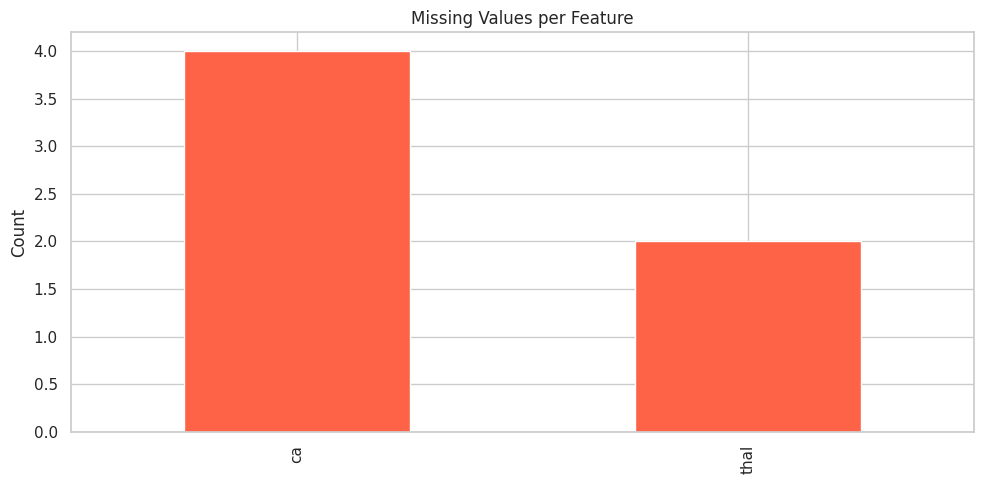

In [14]:
plt.figure(figsize=(10,5))

missing_values[missing_values > 0].plot(
    kind="bar",
    color="tomato"
)
plt.title("Missing Values per Feature")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/missing_values.png", dpi=300)
plt.show()

Target Distribution

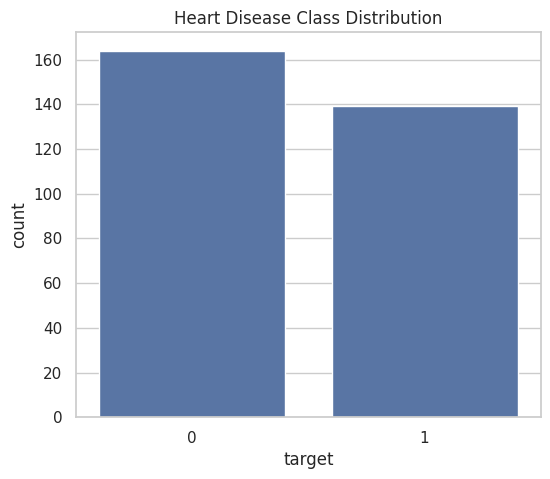

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Heart Disease Class Distribution")
plt.savefig("../reports/class_distribution.png", dpi=300)

plt.show()

In [16]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

## Feature Distributions

This section visualizes the distribution of each numerical feature to identify skewness, outliers, and overall data patterns.

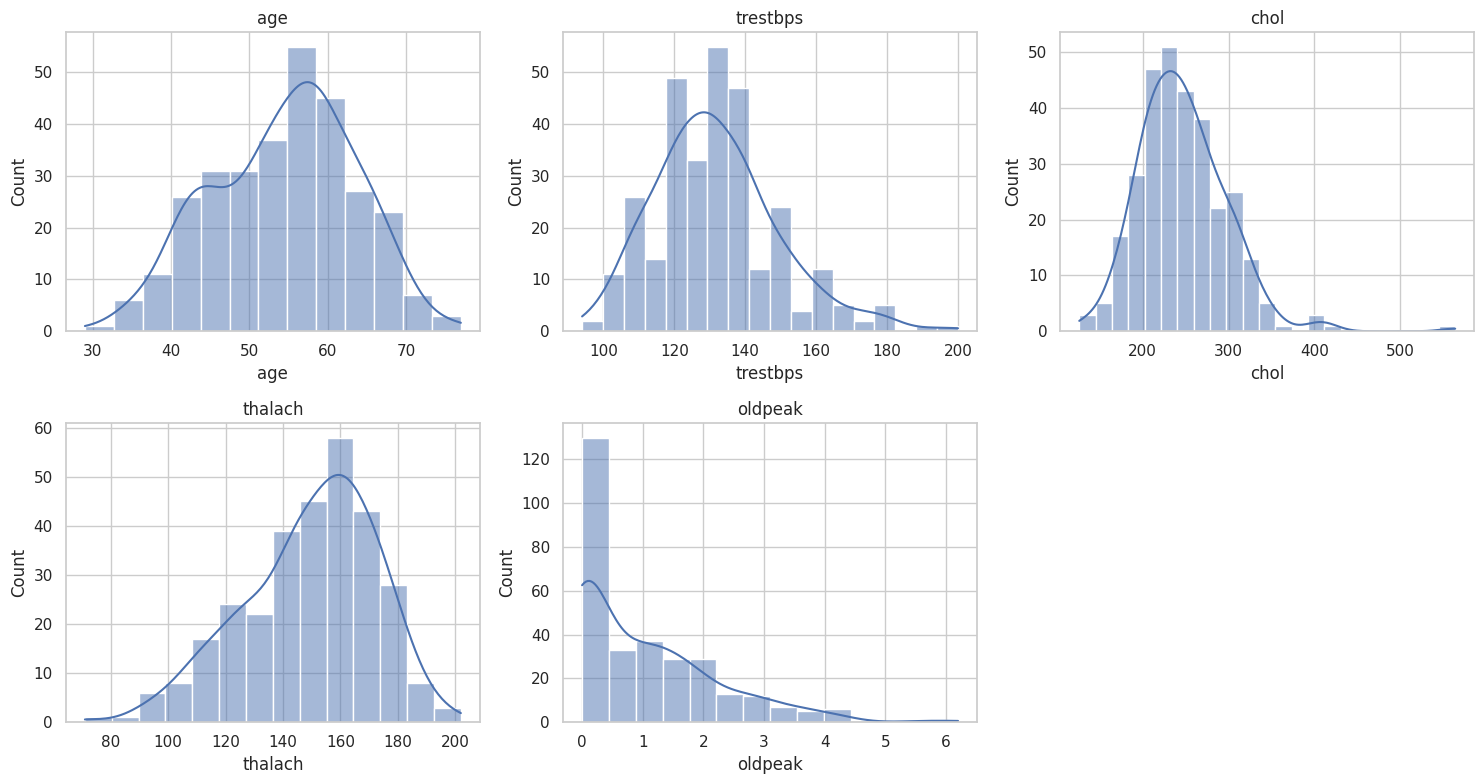

In [17]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax
    )
    ax.set_title(column)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()

plt.savefig("../reports/feature_histograms.png", dpi=300)

plt.show()

### Observations

- Age is approximately normally distributed.
- Cholesterol exhibits a right-skewed distribution.
- Maximum heart rate (`thalach`) spans a wide range.
- ST depression (`oldpeak`) is positively skewed with many low values.

## Correlation Analysis

The correlation heatmap illustrates linear relationships among numerical variables.

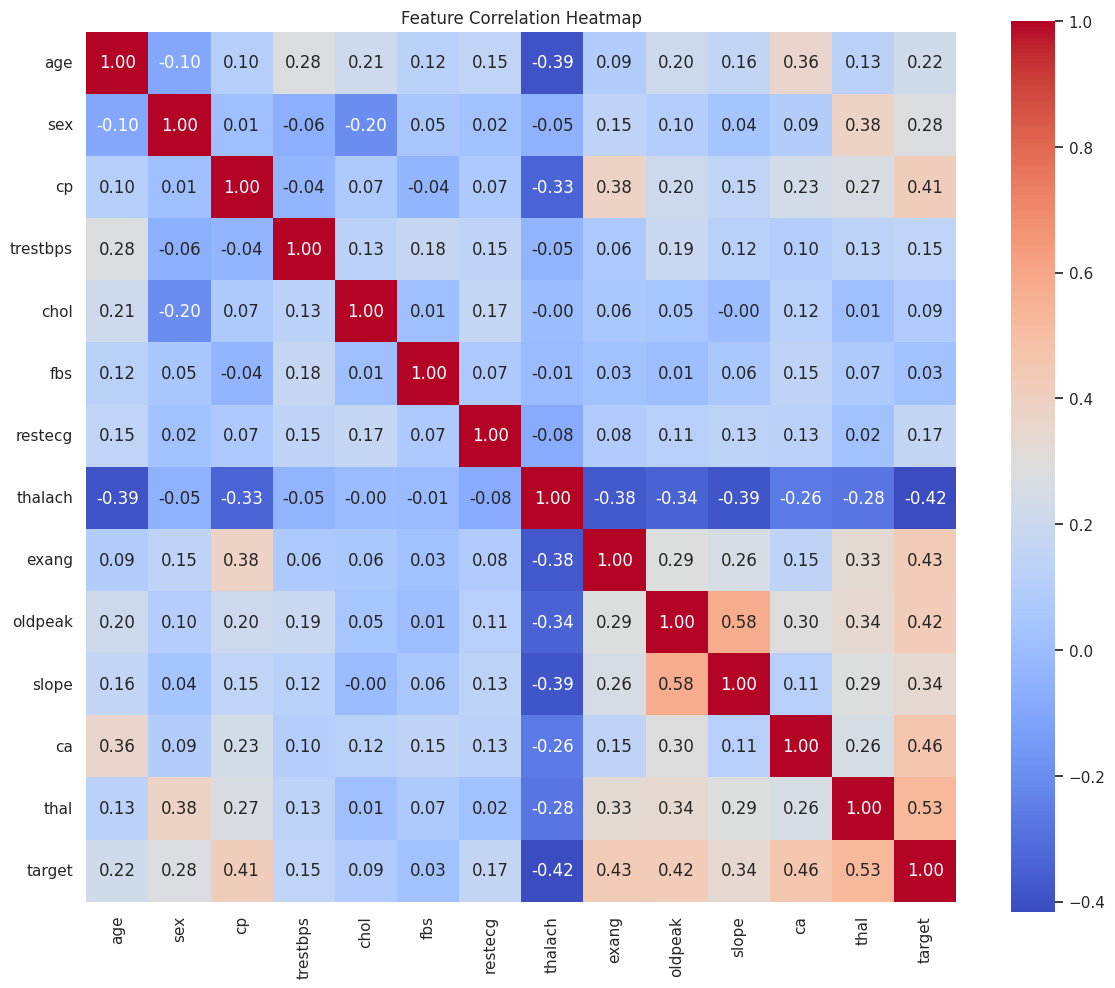

In [18]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig("../reports/correlation_heatmap.png", dpi=300)

plt.show()

### Observations

- `target` is positively correlated with `oldpeak`.
- `target` is negatively correlated with `thalach`.
- Most predictor variables show weak to moderate correlations, suggesting limited multicollinearity.

## Relationship Between Age and Heart Disease

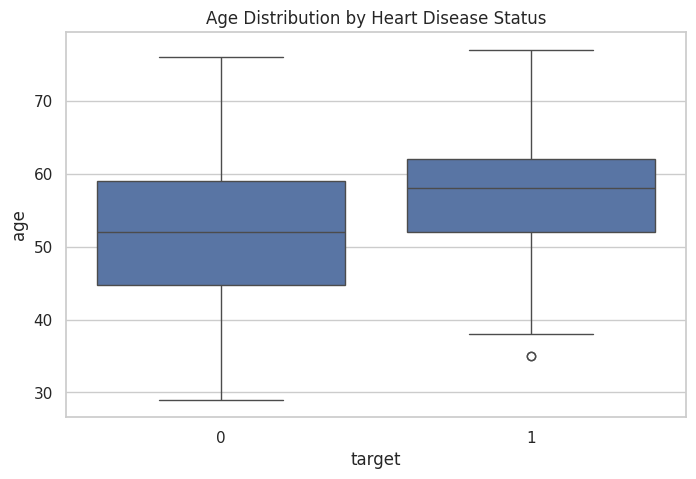

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="age"
)

plt.title("Age Distribution by Heart Disease Status")

plt.savefig("../reports/age_vs_target.png", dpi=300)

plt.show()

Patients diagnosed with heart disease tend to be older on average, although there is overlap between the two groups.

### Chest Pain Type vs Target

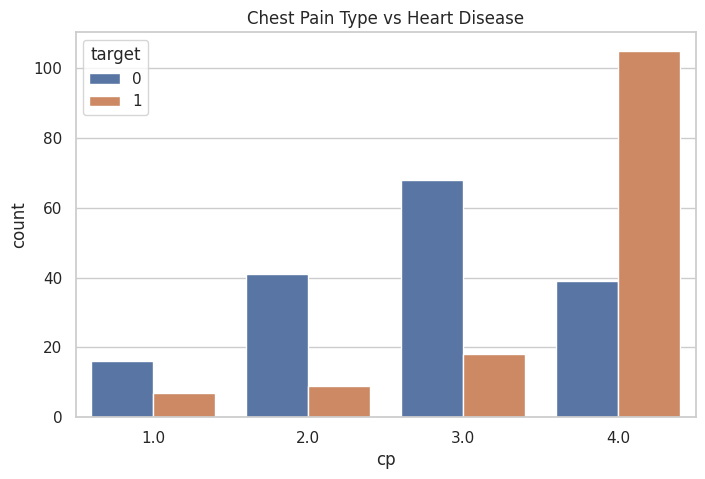

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="cp",
    hue="target"
)

plt.title("Chest Pain Type vs Heart Disease")

plt.savefig("../reports/chest_pain_vs_target.png", dpi=300)

plt.show()

Certain chest pain categories are associated with a higher prevalence of heart disease, indicating that this feature may have predictive value.

### Correlation with Target
It quickly identifies the strongest predictors.

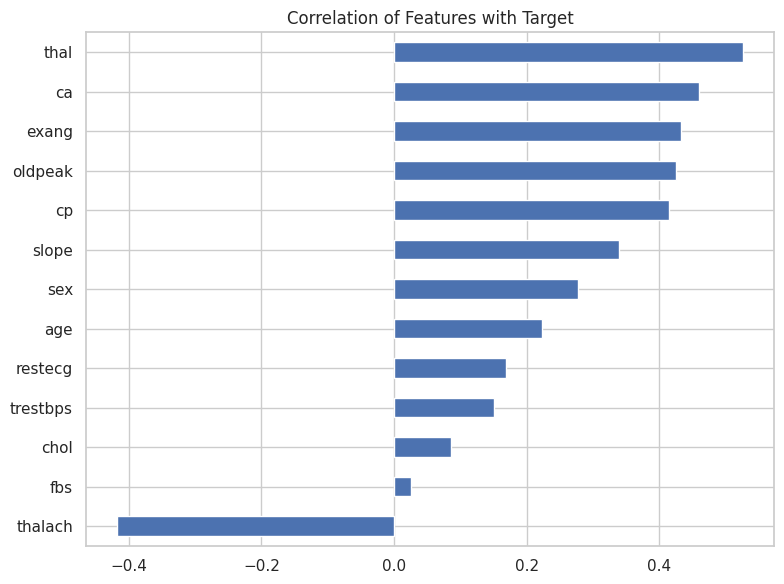

In [21]:
correlation = (
    df.corr()["target"]
    .drop("target")
    .sort_values()
)

plt.figure(figsize=(8, 6))
correlation.plot(kind="barh")
plt.title("Correlation of Features with Target")
plt.tight_layout()
plt.savefig("../reports/target_correlation.png", dpi=300)
plt.show()

# EDA Conclusions

The exploratory analysis of the UCI Cleveland Heart Disease dataset revealed the following:

1. The dataset contains 303 observations and 14 attributes.
2. Missing values are present only in the `ca` and `thal` features.
3. The target classes are reasonably balanced.
4. Numerical features exhibit diverse distributions, with some showing positive skewness.
5. Maximum heart rate (`thalach`) and ST depression (`oldpeak`) demonstrate notable relationships with the target.
6. Correlation analysis indicates limited multicollinearity among predictors.
7. The dataset is suitable for supervised binary classification after appropriate preprocessing.